In [ ]:

import torch
import numpy as np
import pandas as pd

from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)
from peft import PeftModel
from nltk.translate.bleu_score import sentence_bleu
from rouge_score import rouge_scorer
from bert_score import score as bertscore
from tqdm import tqdm

In [ ]:
dataset = load_dataset("json",data_files="../dataset/finetune_dataset.json")["train"]
split_1 = dataset.train_test_split(test_size=0.2,seed=42)
temp_dataset = split_1["test"]
split_2 = temp_dataset.train_test_split(test_size=0.5,seed=42)
test_dataset = split_2["test"]
print("Test Size:", len(test_dataset))

Test Size: 3211


In [ ]:
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

model = PeftModel.from_pretrained(base_model,"../medical_lora_adapter")
model.eval()
print("LoRA Loaded")

LoRA Loaded


In [5]:
evaluation_size = 100

In [ ]:
ground_truths = []
predictions = []
evaluation_size = 100
samples = test_dataset.select(
    range(
        min(
            evaluation_size,
            len(test_dataset)
        )
    )
)

for sample in tqdm(samples):

    prompt = f"""### Instruction:
{sample['instruction']}

### Question:
{sample['input']}

### Response:
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(model.device)

    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_new_tokens=128,
            do_sample=False
        )

    generated_text = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    prediction = generated_text.split(
        "### Response:"
    )[-1].strip()

    predictions.append(prediction)

    ground_truths.append(
        sample["output"]
    )

print("Generated:", len(predictions))

100%|██████████| 100/100 [05:35<00:00,  3.35s/it]

Generated: 100


In [7]:
bleu_scores = []

for pred, gt in zip(
    predictions,
    ground_truths
):

    bleu_scores.append(
        sentence_bleu(
            [gt.split()],
            pred.split()
        )
    )

bleu = np.mean(bleu_scores)

print("BLEU:", bleu)

BLEU: 0.13626080695997644


c:\Users\ROG\anaconda3\envs\RAG_model_chatbot_env\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
c:\Users\ROG\anaconda3\envs\RAG_model_chatbot_env\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
c:\Users\ROG\anaconda3\envs\RAG_model_chatbot_env\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it cont

In [ ]:
scorer = rouge_scorer.RougeScorer(
    ["rouge1", "rougeL"],
    use_stemmer=True
)

rouge1_scores = []
rougeL_scores = []

for pred, gt in zip(predictions,ground_truths):
    scores = scorer.score(gt,pred)
    rouge1_scores.append(scores["rouge1"].fmeasure)
    rougeL_scores.append(scores["rougeL"].fmeasure)
    
rouge1 = np.mean(rouge1_scores)
rougeL = np.mean(rougeL_scores)

print("ROUGE-1:", rouge1)
print("ROUGE-L:", rougeL)

ROUGE-1: 0.42517820945703183
ROUGE-L: 0.3285229945235812


In [ ]:
P, R, F1 = bertscore(
    predictions,
    ground_truths,
    lang="en",
    verbose=True
)

bert_f1 = F1.mean().item()
print("BERTScore:", bert_f1)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


100%|██████████| 3/3 [00:02<00:00,  1.30it/s]


computing greedy matching.


100%|██████████| 2/2 [00:00<00:00, 21.41it/s]

done in 2.40 seconds, 41.60 sentences/sec
BERTScore: 0.8715993762016296


In [10]:
results = pd.DataFrame([{
    "BLEU": bleu,
    "ROUGE-1": rouge1,
    "ROUGE-L": rougeL,
    "BERTScore": bert_f1
}])

results

,BLEU,ROUGE-1,ROUGE-L,BERTScore
0,0.136261,0.425178,0.328523,0.871599


In [ ]:
results.to_csv("lora_evaluation.csv",index=False)
print("Saved")

Saved


In [12]:
import matplotlib.pyplot as plt

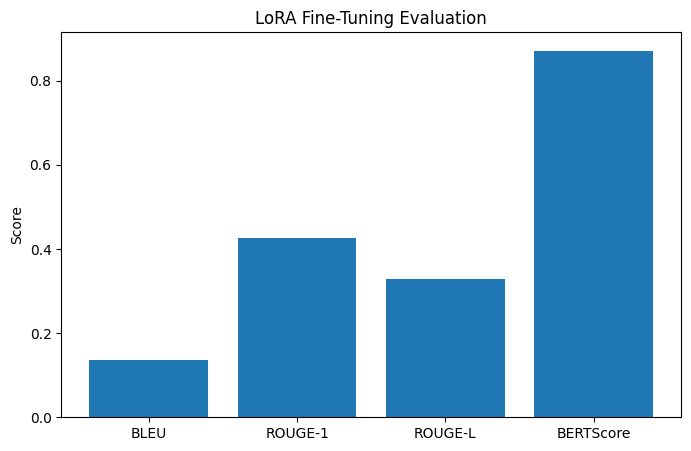

In [ ]:
metrics = [
    "BLEU",
    "ROUGE-1",
    "ROUGE-L",
    "BERTScore"
]

values = [
    bleu,
    rouge1,
    rougeL,
    bert_f1
]

plt.figure(figsize=(8,5))
plt.bar(metrics,values)
plt.title("LoRA Fine-Tuning Evaluation")
plt.ylabel("Score")
plt.show()